# Reference based annotation of cells 


In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scgeo as sg
from scipy import sparse


In [2]:

ref = sc.read_h5ad("data/hematlas_mouse_cross_stage_clean.h5ad")

print(ref)
print("\nFirst 20 var_names:")
print(ref.var_names[:20].tolist())

print("\nCell_type examples:")
print(ref.obs["Cell_type"].astype(str).value_counts().head(20))

print("\nStage examples:")
print(ref.obs["stage"].astype(str).value_counts())

print("\nX type:", type(ref.X))
if sparse.issparse(ref.X):
    print("X nnz:", ref.X.nnz)

print("\nUMAP shape:", ref.obsm["UMAP"].shape)

AnnData object with n_obs × n_vars = 73878 × 27285
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'ident', 'sum', 'detected', 'percent_top_50', 'percent_top_100', 'percent_top_200', 'percent_top_500', 'subsets_Mito_sum', 'subsets_Mito_detected', 'subsets_Mito_percent', 'total', 'nCount_SCT', 'nFeature_SCT', 'dataset', 'integrated_snn_res.1', 'seurat_clusters', 'integrated_snn_res.0.5', 'integrated_snn_res.0.1', 'integrated_snn_res.0.2', 'Cell_type', 'integrated_snn_res.0.3', 'cell', 'stage'
    uns: 'X_name'
    obsm: 'UMAP'
    layers: 'logcounts'

First 20 var_names:
['Xkr4', 'Gm1992', 'Gm19938', 'Rp1', 'Sox17', 'Gm37587', 'Mrpl15', 'Lypla1', 'Tcea1', 'Rgs20', 'Atp6v1h', 'Oprk1', 'Npbwr1', 'Rb1cc1', '4732440D04Rik', 'Alkal1', 'St18', 'Pcmtd1', 'Gm26901', 'Sntg1']

Cell_type examples:
Cell_type
Hematopoietic stem and progenitor cell    13641
Mesenchymal stem and progenitor cell       8282
Venous endothelial cell                    6761
Erythroblast                 

In [3]:

# standardize obs labels
ref.obs["celltype"] = ref.obs["Cell_type"].astype(str)
ref.obs["stage"] = ref.obs["stage"].astype(str)

# standardize embedding name for scanpy/scgeo convenience
ref.obsm["X_umap"] = np.asarray(ref.obsm["UMAP"])

# optional cleanup: keep only the most useful obs columns
keep_obs = [
    "celltype", "stage", "dataset", "orig.ident", "seurat_clusters"
]
keep_obs = [c for c in keep_obs if c in ref.obs.columns]
ref.obs = ref.obs[keep_obs].copy()

ref.write("data/hematlas_mouse_cross_stage_scgeo_ready.h5ad")
print(ref)

AnnData object with n_obs × n_vars = 73878 × 27285
    obs: 'celltype', 'stage', 'dataset', 'orig.ident', 'seurat_clusters'
    uns: 'X_name'
    obsm: 'UMAP', 'X_umap'
    layers: 'logcounts'


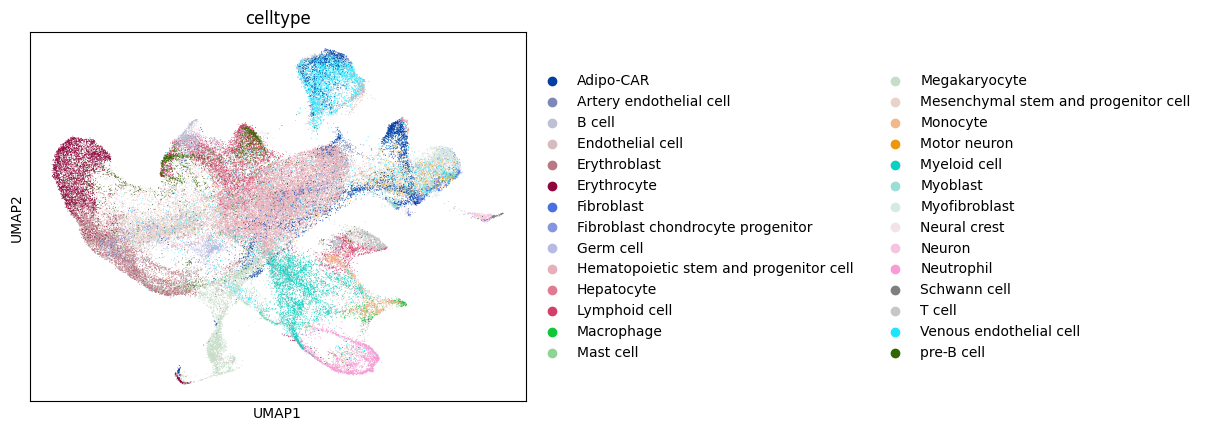

In [4]:
sc.pl.umap(ref, color='celltype')

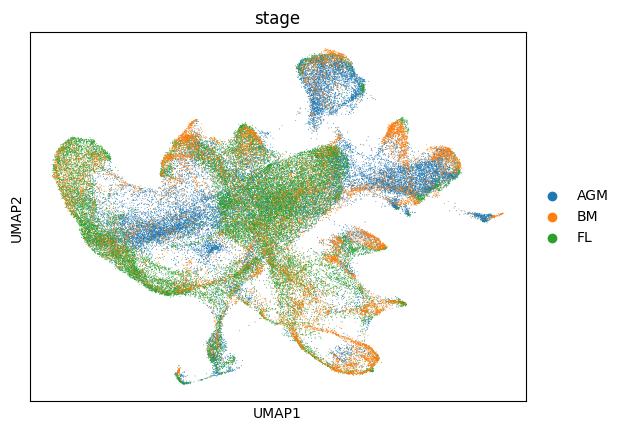

In [5]:
sc.pl.umap(ref, color='stage')

In [6]:

adata=sc.read_h5ad("data/GSE280305_for_Ref.h5ad")

In [7]:

print(adata)

AnnData object with n_obs × n_vars = 31605 × 3000
    obs: 'timepoint', 'sample', 'gsm', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden_raw', 'scgeo_pred', 'scgeo_conf_entropy', 'scgeo_conf_margin', 'scgeo_conf', 'scgeo_ood', 'scgeo_reject', 'alignment_group', 'cluster_label_mannual'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'cluster_label_mannual_colors', 'hvg', 'leiden_raw', 'leiden_raw_colors', 'log1p', 'nbrs_raw', 'nbrs_scanorama', 'pca', 'rank_genes_groups', 'scgeo', 'timepoint_c

In [8]:
adata.var

,Accession,Chromosome,End,Start,Strand,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches,mean,std
Gene,,,,,,,,,,,,,,,,,,,,
1200007C13Rik,ENSMUSG00000087684,2,167833646,167827693,-,False,418,0.019649,0.019458,98.677424,621.0,6.432940,True,1362.5,0.008763,0.009249,1.316818,2,0.008763,0.096173
1700001C02Rik,ENSMUSG00000029182,5,30484088,30466047,+,False,6,0.000221,0.000221,99.981016,7.0,2.079442,True,1305.0,0.000178,0.000274,0.369016,1,0.000178,0.016566
1700001K19Rik,ENSMUSG00000056508,12,110682619,110667688,-,False,1886,0.094542,0.090336,94.032590,2988.0,8.002694,True,1199.0,0.031362,0.028502,1.228367,1,0.031362,0.168824
1700001K23Rik,ENSMUSG00000118314,19,53265405,53248736,-,False,73,0.002373,0.002370,99.769024,75.0,4.330733,True,1360.0,0.000800,0.000614,0.888700,1,0.000800,0.024774
1700001P01Rik,ENSMUSG00000018543,11,97775918,97771481,-,False,191,0.006138,0.006120,99.395665,194.0,5.273000,True,1157.0,0.002633,0.002412,1.013123,1,0.002633,0.049109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
mt-Nd2,ENSMUSG00000064345,M,4951,3914,+,True,30861,25.667774,3.283456,2.354058,811230.0,13.606308,True,206.5,2.697205,1.820285,2.523571,4,2.697205,1.349179
mt-Nd3,ENSMUSG00000064360,M,9806,9459,+,True,20816,1.770922,1.019180,34.137004,55970.0,10.932589,True,80.5,0.698871,0.924024,2.888742,4,0.698871,0.961261
mt-Nd4,ENSMUSG00000064363,M,11544,10167,+,True,31159,34.324569,3.564579,1.411169,1084828.0,13.896933,True,296.5,3.043209,1.811149,2.301795,4,3.043209,1.345789


In [9]:
shared = ref.var_names.intersection(adata.var_names)
print("shared genes:", len(shared))
print(shared[:20].tolist())

shared genes: 2910
['Sox17', '1700034P13Rik', 'Prex2', 'Eya1', 'Trpa1', 'Kcnb2', 'Gm28376', 'Gm16070', 'Tfap2d', 'Kcnq5', '4931428L18Rik', 'Khdrbs2', 'Bend6', 'Neurl3', 'Zap70', 'Aff3', 'Lonrf2', 'Tbc1d8', 'Rfx8', 'Il1r2']


In [10]:
ref=ref[:, shared]

In [11]:
ref.write("data/hematlas_mouse_cross_shorten.h5ad")

In [12]:
print(ref)

View of AnnData object with n_obs × n_vars = 73878 × 2910
    obs: 'celltype', 'stage', 'dataset', 'orig.ident', 'seurat_clusters'
    uns: 'X_name', 'celltype_colors', 'stage_colors'
    obsm: 'UMAP', 'X_umap'
    layers: 'logcounts'
